Plot habitability graphs against planetary parameter

In [6]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

Choose the planetary parameter you want to test

In [7]:
# ROTATION
rot_earth = 7.2921159e-5
rot_rate = np.arange(0.1,2.1,0.1)
print(rot_rate)

# AXIAL TILT
at_arr = np.arange(-45,55,10)
print(at_arr)

# SOLAR FLUX 
sf_array = np.arange(800,1900,100)
print(sf_array)

# ATMOSPHERIC THICKNESS
atm_arr = np.arange(50000,160000,10000)
print(atm_arr)

# GRAVITY
g_arr = np.arange(10,110,10)
print(g_arr)

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2. ]
[-45 -35 -25 -15  -5   5  15  25  35  45]
[ 800  900 1000 1100 1200 1300 1400 1500 1600 1700 1800]
[ 50000  60000  70000  80000  90000 100000 110000 120000 130000 140000
 150000]
[ 10  20  30  40  50  60  70  80  90 100]


Uncomment your desired dataset

In [8]:
# ROTATION
#ds = xr.open_dataset("rotation_trials/output_rot_11.nc")

# AXIAL TILT
#ds =  xr.open_dataset("axial_tilt_trials_2yr/output_rot_9.nc")

# SOLAR FLUX
#ds =  xr.open_dataset("solar_flux_trials/output_rot_11.nc")

# ATMOSPHERIC THICKNESS
ds = xr.open_dataset("atmos_trials/output_rot_11.nc")

# GRAVITY
ds = xr.open_dataset("grav_trials/output_rot_10.nc")

Create your empty arrays

In [9]:
hab_sm_arr = []
hab_st_arr = []
hab_tsurf_arr = []

Uncomment your desired path and calculate habitability 

Note you may need to change the index range for shorter/longer datasets

In [10]:
# Habitability fraction for surface soil temperature

hab_frac_st = []

for idx in range(1, 11):

    # ROTATION
    #path = f"rotation_trials/output_rot_{idx}.nc"

    # AXIAL TILT
    #path = f"axial_tilt_trials_2yr/output_rot_{idx}.nc"

    # SOLAR FLUX
    #path = f"solar_flux_trials/output_rot_{idx}.nc"

    # ATMOSPHERIC THICKNESS
    #path = f"atmos_trials/output_rot_{idx}.nc"

    # GRAVITY
    path = f"grav_trials/output_rot_{idx}.nc"

    ds = xr.open_dataset(path)

    # Extract desired variables
    st = ds["st"].isel(soil_layer=0)
    sm = ds["sm"].isel(soil_layer=0)
    tsurf = ds["tsurf"]

    # Create masked dataframes
    da_st = st.mean(dim="time")
    da_sm = sm.mean(dim="time")
    da_tsurf = tsurf.mean(dim="time")

    # Create a land mask 
    land = da_sm > 1e-6

    # Creating habitability masks
    hab_sm = (da_sm >= 0.1) & land
    hab_st = (da_st >= 0) & (da_st <= 48) & land
    hab_tsurf = (da_tsurf >= 0) & (da_tsurf <= 48) & land

    # latitude-based area weights
    lat = sm.lat
    weights = np.cos(np.deg2rad(lat))
    weights = weights.where(np.isfinite(weights), 0)

    # area-weighted habitability (%)
    hab_frac_st = ((hab_st * weights).sum() / (land * weights).sum()) * 100
    hab_frac_st = hab_frac_st.item()
    hab_st_arr.append(hab_frac_st)

    hab_frac_sm = ((hab_sm * weights).sum() / (land * weights).sum()) * 100
    hab_frac_sm = hab_frac_sm.item()
    hab_sm_arr.append(hab_frac_sm)

    hab_frac_tsurf = ((hab_tsurf * weights).sum() / (land * weights).sum()) * 100
    hab_frac_tsurf = hab_frac_tsurf.item()
    hab_tsurf_arr.append(hab_frac_tsurf)

    print(hab_frac_st, hab_frac_sm, hab_frac_tsurf)


75.76344635161055 92.86512545155261 68.37797254516586
33.55479744860339 80.03405588003596 68.50790347042762
58.39440799951786 84.00183243695693 67.07695466590305
36.81442251655968 73.02711543955506 67.98172634673796
38.11383601715409 73.60445138911537 68.029455031289
41.220887979472735 72.90356125092472 67.98172634673796
41.0922622298515 73.95826229737172 68.10402368282023
44.55054840728632 73.0856826820188 69.45361481557629
55.308804715824486 73.50064647627906 70.00648751717947
53.977280080911946 75.00634711327652 70.1693559183802


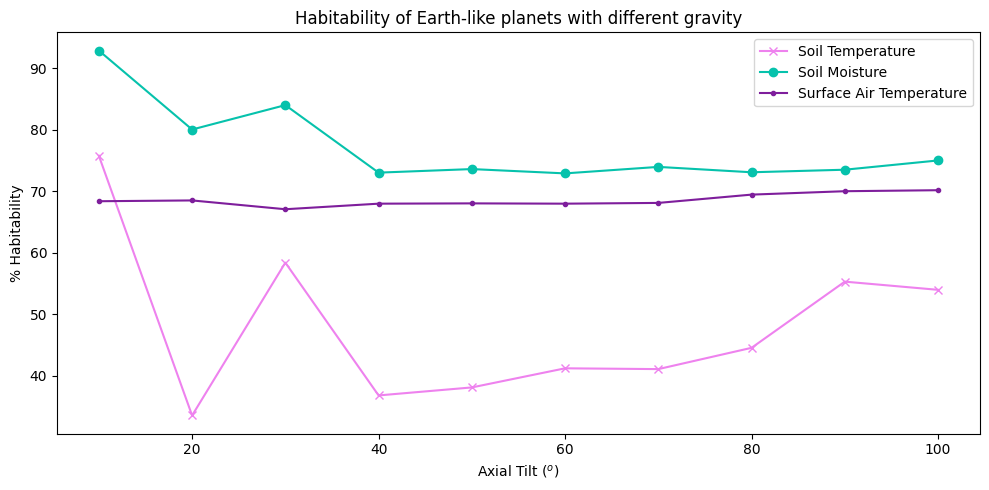

In [11]:
# ROTATION
# x = rot_rate
# metric = "rotation rates"

# # AXIAL TILT
# x = at_arr
# metric = "axial tilts"

# # SOLAR FLUX 
# x = sf_array
# metric = "solar fluxes"

# # ATMOSPHERIC THICKNESS
# x = atm_arr
# metric = "atmospheric thicknesses"

# # GRAVITY
x = g_arr
metric = "gravity"

fig = plt.figure(figsize=(10, 5))

#plt.plot(atm_arr, hab_frac_sm, marker='o', linestyle='-', color='r')

plt.plot(x, hab_st_arr, marker='x', color='#EE82EE', label="Soil Temperature")
plt.plot(x, hab_sm_arr, marker='o', color='#06C2AC', label="Soil Moisture")
plt.plot(x, hab_tsurf_arr, marker='.', color ='#7E1E9C', label="Surface Air Temperature")

plt.xlabel('Axial Tilt ($^o$)')
plt.ylabel('% Habitability')
plt.title(f"Habitability of Earth-like planets with different {metric}")
plt.legend()
plt.tight_layout()
plt.show()